# Minh họa từng bước trích xuất đặc trưng bằng MediaPipe

Notebook bám theo pipeline `base` thật trong `engagement_daisee.rnn.extract_features`:

1. Đọc video và chọn khung hình.
2. MediaPipe Face Landmarker phát hiện các điểm mốc khuôn mặt.
3. Từ landmark tính EAR hai mắt, MAR và ba đại lượng hình học đầu.
4. Ghép thêm tọa độ $(x,y,z)$ của 8 landmark để tạo vector **30 chiều/frame**.
5. Ghép giá trị gốc, vận tốc và độ lệch chuẩn cửa sổ để tạo **90 chiều/frame**.
6. Một cửa sổ gồm 30 frame có kích thước cuối cùng $(30,90)$.

> Có thể đổi `VIDEO_PATH` ở cell cấu hình để khảo sát một video khác.

In [1]:
from pathlib import Path
import os
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Video

def find_repo_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'src' / 'engagement_daisee').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục gốc engagement-cpu')

ROOT = find_repo_root()
sys.path.insert(0, str(ROOT / 'src'))

# Nạp trực tiếp file trích xuất để không kích hoạt rnn/__init__.py và PyTorch.
# Các hàm dưới đây vẫn chính là implementation đang được pipeline huấn luyện sử dụng.
import importlib.util
extractor_path = ROOT / 'src' / 'engagement_daisee' / 'rnn' / 'extract_features.py'
spec = importlib.util.spec_from_file_location('engagement_extract_features_demo', extractor_path)
extractor = importlib.util.module_from_spec(spec)
spec.loader.exec_module(extractor)
LEFT_EYE = extractor.LEFT_EYE
RIGHT_EYE = extractor.RIGHT_EYE
BASE_LANDMARKS = extractor.BASE_LANDMARKS
_build_frame_feature = extractor._build_frame_feature
_create_face_landmarker = extractor._create_face_landmarker
_frame_feature_dim = extractor._frame_feature_dim
_window_frames = extractor._window_frames

OUT = ROOT / 'notebooks' / 'preprocess'
OUT.mkdir(parents=True, exist_ok=True)

# Đổi đường dẫn này nếu muốn phân tích video khác. Để None sẽ tự tìm một video DAiSEE.
VIDEO_PATH = None
if VIDEO_PATH is None:
    preferred = ROOT.parent / 'Engagement_DAiSEE' / 'data' / 'raw' / 'daisee' / 'DAiSEE' / 'DataSet' / 'Test' / '500044' / '5000441001' / '5000441001.avi'
    local_videos = list((ROOT / 'data' / 'raw').rglob('*.avi')) if (ROOT / 'data' / 'raw').exists() else []
    sibling_root = ROOT.parent / 'Engagement_DAiSEE' / 'data' / 'raw' / 'daisee' / 'DAiSEE' / 'DataSet'
    sibling_videos = list(sibling_root.rglob('*.avi')) if sibling_root.exists() else []
    candidates = ([preferred] if preferred.exists() else []) + local_videos + sibling_videos
    if not candidates:
        raise FileNotFoundError('Không tìm thấy video. Hãy gán VIDEO_PATH ở cell cấu hình.')
    VIDEO_PATH = candidates[0]
VIDEO_PATH = Path(VIDEO_PATH).expanduser().resolve()

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 220, 'font.family': 'DejaVu Sans'})
print('Repo:', ROOT)
print('Video:', VIDEO_PATH)
print('Đầu ra:', OUT)

Repo: /home/bear/Documents/Workspace/Thesis20252/engagement-cpu
Video: /home/bear/Documents/Workspace/Thesis20252/Engagement_DAiSEE/data/raw/daisee/DAiSEE/DataSet/Test/500044/5000441001/5000441001.avi
Đầu ra: /home/bear/Documents/Workspace/Thesis20252/engagement-cpu/notebooks/preprocess


## 1. Landmark nào tạo ra feature nào?

MediaPipe trả tọa độ chuẩn hóa của landmark: $x,y\in[0,1]$ theo chiều rộng/cao ảnh; $z$ biểu diễn độ sâu tương đối. Pipeline `base` không đưa toàn bộ mesh vào mô hình mà chọn các tỷ lệ hình học và 8 điểm đại diện.

- **EAR mắt trái:** 33, 160, 158, 133, 153, 144.
- **EAR mắt phải:** 362, 385, 387, 263, 373, 380.
- **MAR:** môi trên 13, môi dưới 14, khóe trái 61, khóe phải 291.
- **Hình học đầu:** mũi 1, cằm 152, hai góc mắt 33/263 và hai khóe miệng 61/291.
- **Tọa độ đưa trực tiếp vào vector:** 33, 133, 362, 263, 61, 291, 13, 14.

In [2]:
LANDMARK_NAMES = {
    1: 'Đầu mũi', 13: 'Môi trên', 14: 'Môi dưới', 33: 'Góc ngoài mắt trái',
    133: 'Góc trong mắt trái', 152: 'Cằm', 263: 'Góc ngoài mắt phải',
    362: 'Góc trong mắt phải', 61: 'Khóe miệng trái', 291: 'Khóe miệng phải',
}
schema_rows = [
    {'Chỉ số': 0, 'Feature': 'left_ear', 'Nguồn landmark': str(LEFT_EYE), 'Ý nghĩa': 'Độ mở mắt trái'},
    {'Chỉ số': 1, 'Feature': 'right_ear', 'Nguồn landmark': str(RIGHT_EYE), 'Ý nghĩa': 'Độ mở mắt phải'},
    {'Chỉ số': 2, 'Feature': 'mouth_aspect_ratio', 'Nguồn landmark': '[13, 14, 61, 291]', 'Ý nghĩa': 'Độ mở miệng'},
    {'Chỉ số': 3, 'Feature': 'pitch_proxy', 'Nguồn landmark': '[1, 152, 33, 263, 61, 291]', 'Ý nghĩa': 'Cúi/ngẩng tương đối'},
    {'Chỉ số': 4, 'Feature': 'yaw_proxy', 'Nguồn landmark': '[1, 33, 263]', 'Ý nghĩa': 'Quay trái/phải tương đối'},
    {'Chỉ số': 5, 'Feature': 'roll_proxy', 'Nguồn landmark': '[33, 263]', 'Ý nghĩa': 'Nghiêng đầu'},
]
feature_index = 6
for landmark_id in BASE_LANDMARKS:
    for axis in 'xyz':
        schema_rows.append({
            'Chỉ số': feature_index,
            'Feature': f'lm_{landmark_id}_{axis}',
            'Nguồn landmark': f'{landmark_id} - {LANDMARK_NAMES[landmark_id]}',
            'Ý nghĩa': f'Tọa độ {axis} chuẩn hóa',
        })
        feature_index += 1
FEATURE_SCHEMA = pd.DataFrame(schema_rows)
assert len(FEATURE_SCHEMA) == _frame_feature_dim('base') == 30
display(FEATURE_SCHEMA)
FEATURE_SCHEMA.to_csv(OUT / 'feature_schema_30.csv', index=False, encoding='utf-8-sig')

,Chỉ số,Feature,Nguồn landmark,Ý nghĩa
0,0,left_ear,"[33, 160, 158, 133, 153, 144]",Độ mở mắt trái
1,1,right_ear,"[362, 385, 387, 263, 373, 380]",Độ mở mắt phải
2,2,mouth_aspect_ratio,"[13, 14, 61, 291]",Độ mở miệng
3,3,pitch_proxy,"[1, 152, 33, 263, 61, 291]",Cúi/ngẩng tương đối
4,4,yaw_proxy,"[1, 33, 263]",Quay trái/phải tương đối
5,5,roll_proxy,"[33, 263]",Nghiêng đầu
6,6,lm_33_x,33 - Góc ngoài mắt trái,Tọa độ x chuẩn hóa
7,7,lm_33_y,33 - Góc ngoài mắt trái,Tọa độ y chuẩn hóa
8,8,lm_33_z,33 - Góc ngoài mắt trái,Tọa độ z chuẩn hóa
9,9,lm_133_x,133 - Góc trong mắt trái,Tọa độ x chuẩn hóa


## 2. MediaPipe hoạt động trên một khung hình

Cell dưới đọc frame giữa video, chuyển BGR→RGB rồi gọi Face Landmarker. Hình bên trái là frame gốc; hình giữa là toàn bộ landmark; hình phải nhấn mạnh các điểm thực sự tham gia vector 30 chiều.

W0000 00:00:1782299800.144874  117487 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782299800.204910  117487 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782299800.211708  117502 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Iris(R) Xe Graphics (TGL GT2)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1782299800.219072  117492 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782299800.254066  117489 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


{'frames': 300, 'fps': 30.0, 'size': (640, 480), 'frame_chọn': 150, 'landmarks_phát_hiện': 478}


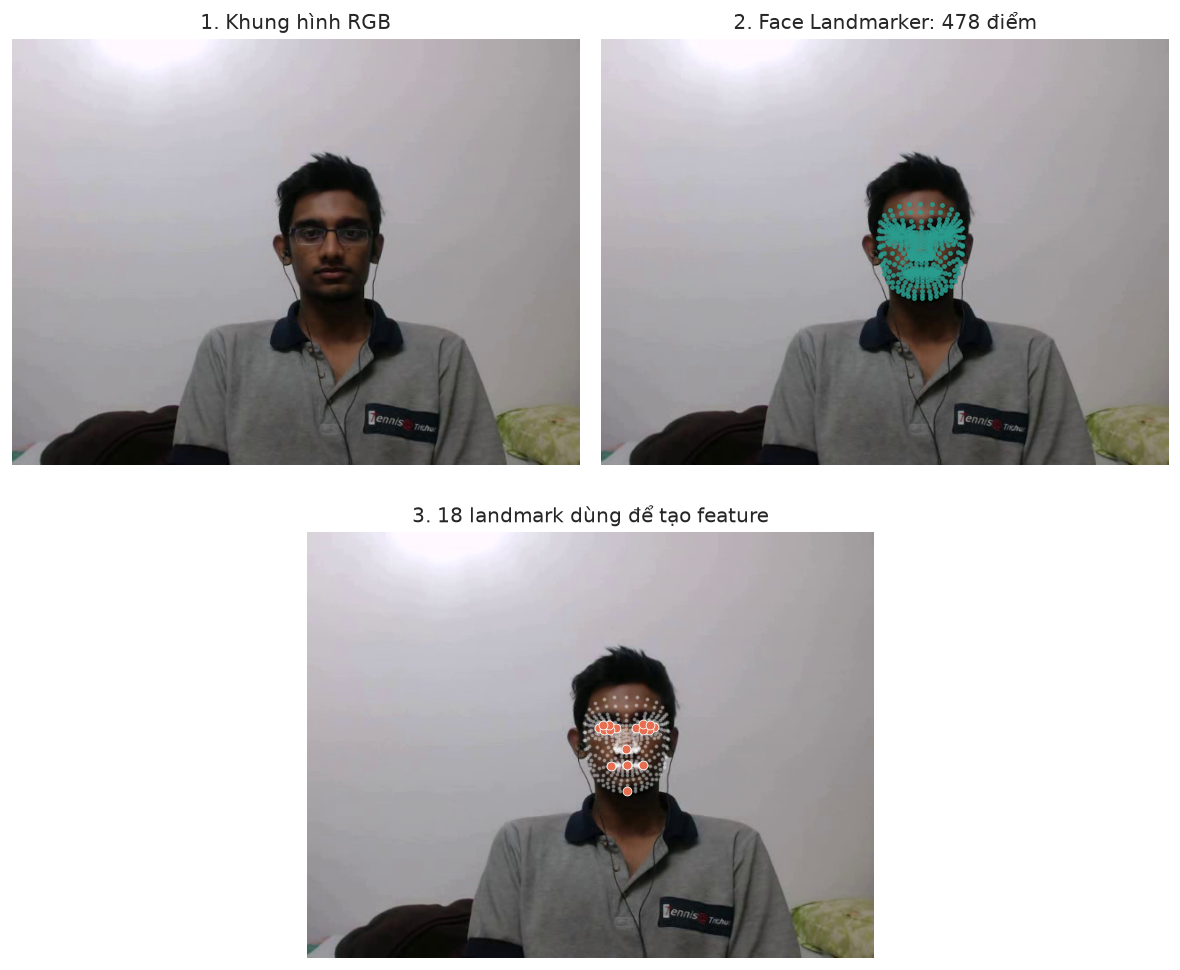

In [3]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
fps = float(cap.get(cv2.CAP_PROP_FPS) or 0.0)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or 0)
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
middle_index = max(0, frame_count // 2)
cap.set(cv2.CAP_PROP_POS_FRAMES, middle_index)
ok, frame_bgr = cap.read()
cap.release()
if not ok:
    raise RuntimeError('Không đọc được frame giữa video')
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

detector = _create_face_landmarker()
result = detector.process(frame_rgb)
if not result.multi_face_landmarks:
    raise RuntimeError('MediaPipe không tìm thấy khuôn mặt ở frame giữa')
face = result.multi_face_landmarks[0]
points = np.asarray([[lm.x * width, lm.y * height, lm.z] for lm in face.landmark], dtype=float)
print({'frames': frame_count, 'fps': fps, 'size': (width, height), 'frame_chọn': middle_index, 'landmarks_phát_hiện': len(points)})

import matplotlib.gridspec as gridspec
selected_ids = sorted(set(LEFT_EYE + RIGHT_EYE + [1, 13, 14, 61, 152, 263, 291]))
fig = plt.figure(figsize=(10, 8.5))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2:])
ax3 = fig.add_subplot(gs[1, 1:3])

axes = [ax1, ax2, ax3]
for ax in axes:
    ax.imshow(frame_rgb)
    ax.axis('off')
ax1.set_title('1. Khung hình RGB')
ax2.scatter(points[:, 0], points[:, 1], s=4, c='#2A9D8F', alpha=0.75)
ax2.set_title(f'2. Face Landmarker: {len(points)} điểm')
ax3.scatter(points[:, 0], points[:, 1], s=2, c='white', alpha=0.30)
ax3.scatter(points[selected_ids, 0], points[selected_ids, 1], s=28, c='#E76F51', edgecolor='white', linewidth=0.5)
ax3.set_title(f'3. {len(selected_ids)} landmark dùng để tạo feature')
fig.tight_layout()
fig.savefig(OUT / '01_cac_buoc_phat_hien_landmark.png', bbox_inches='tight', facecolor='white')
plt.show()


## 3. Các nhóm landmark và công thức hình học

$$EAR=\frac{\|p_2-p_6\|+\|p_3-p_5\|}{2\|p_1-p_4\|}$$

$$MAR=\frac{\|p_{13}-p_{14}\|}{\|p_{61}-p_{291}\|}$$

EAR giảm khi mắt khép. MAR tăng khi miệng mở. Các proxy pitch/yaw/roll được chuẩn hóa theo kích thước khuôn mặt để giảm ảnh hưởng của khoảng cách camera.

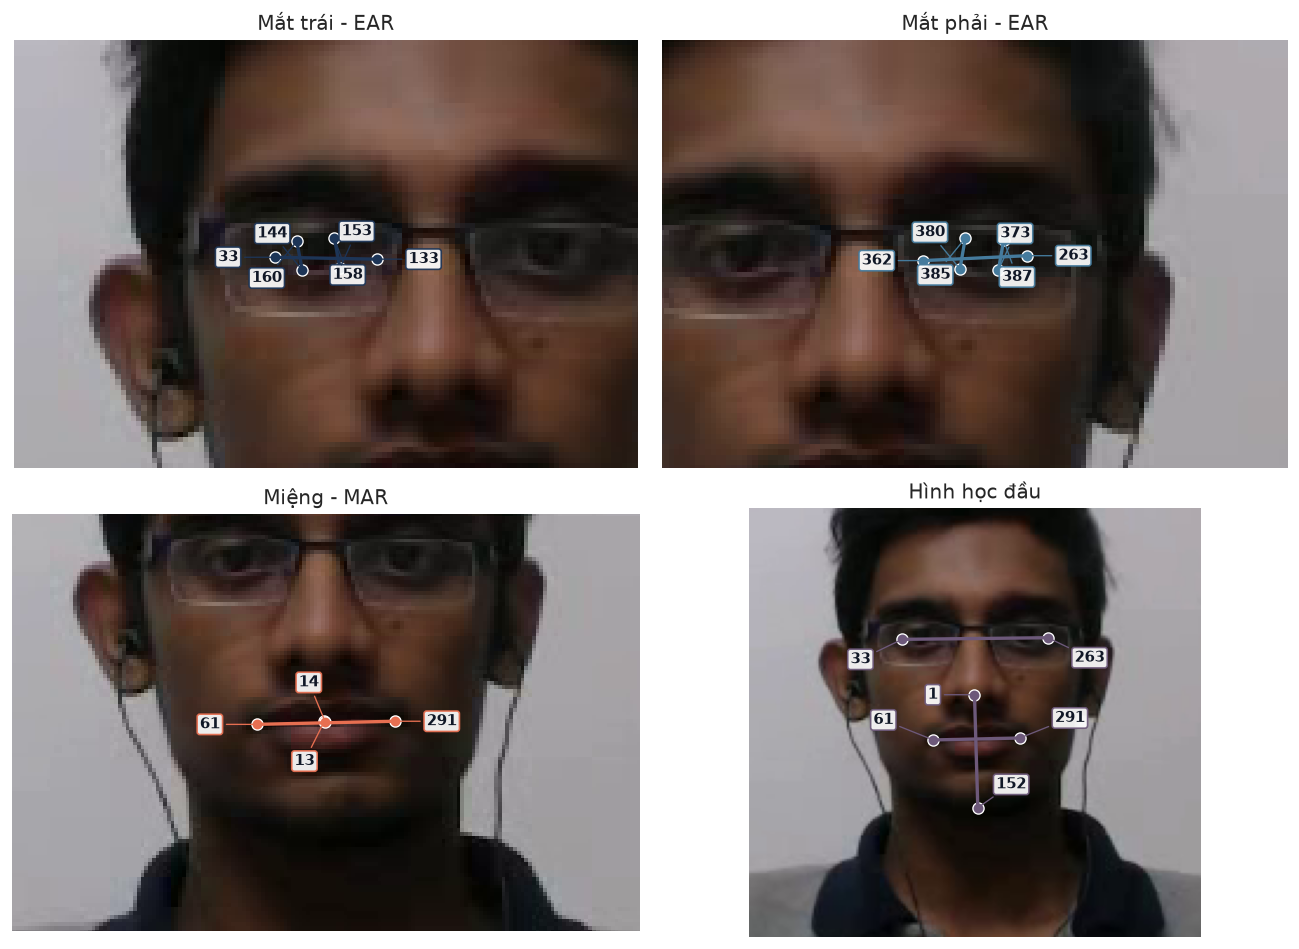

In [4]:
groups = [
    ('Mắt trái - EAR', LEFT_EYE, '#1D3557'),
    ('Mắt phải - EAR', RIGHT_EYE, '#457B9D'),
    ('Miệng - MAR', [61, 13, 291, 14], '#E76F51'),
    ('Hình học đầu', [33, 263, 1, 152, 61, 291], '#6D597A'),
]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
label_offsets = {
    'Mắt trái - EAR': [(-28, 0), (-18, -22), (8, -22), (28, 0), (10, 22), (-18, 22)],
    'Mắt phải - EAR': [(-28, 0), (-18, -22), (8, -22), (28, 0), (10, 22), (-18, 22)],
    'Miệng - MAR': [(-28, 0), (-12, -24), (28, 0), (-10, 24)],
    'Hình học đầu': [(-25, -12), (25, -12), (-25, 0), (20, 14), (-30, 12), (30, 12)],
}
for ax, (title, ids, color) in zip(axes.flat, groups):
    ax.imshow(frame_rgb)
    ax.scatter(points[ids, 0], points[ids, 1], s=45, c=color, edgecolor='white', linewidth=0.8)
    for idx, offset in zip(ids, label_offsets[title]):
        ax.annotate(str(idx), points[idx, :2], xytext=offset, textcoords='offset points',
                    color='#111827', fontsize=9, weight='bold', ha='center', va='center',
                    bbox={'boxstyle': 'round,pad=0.18', 'fc': 'white', 'ec': color, 'alpha': 0.92},
                    arrowprops={'arrowstyle': '-', 'color': color, 'lw': 0.8})
    if 'Mắt' in title:
        for a, b in [(0, 3), (1, 5), (2, 4)]:
            ax.plot(points[[ids[a], ids[b]], 0], points[[ids[a], ids[b]], 1], color=color, lw=2)
    elif 'Miệng' in title:
        ax.plot(points[[61, 291], 0], points[[61, 291], 1], color=color, lw=2)
        ax.plot(points[[13, 14], 0], points[[13, 14], 1], color=color, lw=2)
    else:
        ax.plot(points[[33, 263], 0], points[[33, 263], 1], color=color, lw=2)
        ax.plot(points[[1, 152], 0], points[[1, 152], 1], color=color, lw=2)
        ax.plot(points[[61, 291], 0], points[[61, 291], 1], color=color, lw=2)
    margin_x = 50 if 'Mắt' in title else 65
    margin_y = 38 if 'Mắt' in title else 55
    ax.set_xlim(points[ids, 0].min() - margin_x, points[ids, 0].max() + margin_x)
    ax.set_ylim(points[ids, 1].max() + margin_y, points[ids, 1].min() - margin_y)
    ax.set_title(title)
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUT / '02_nhom_landmark_tao_dac_trung.png', bbox_inches='tight', facecolor='white')
plt.show()

## 4. Vector 30 chiều của frame cụ thể

Cell này gọi trực tiếp `_build_frame_feature(..., feature_set='base')` của repo, sau đó ghép giá trị với bảng schema ở trên.

,Chỉ số,Feature,Nguồn landmark,Ý nghĩa,Giá trị tại frame
0,0,left_ear,"[33, 160, 158, 133, 153, 144]",Độ mở mắt trái,0.385912
1,1,right_ear,"[362, 385, 387, 263, 373, 380]",Độ mở mắt phải,0.393604
2,2,mouth_aspect_ratio,"[13, 14, 61, 291]",Độ mở miệng,0.014664
3,3,pitch_proxy,"[1, 152, 33, 263, 61, 291]",Cúi/ngẩng tương đối,-0.261588
4,4,yaw_proxy,"[1, 33, 263]",Quay trái/phải tương đối,-0.003490
5,5,roll_proxy,"[33, 263]",Nghiêng đầu,-0.014934
6,6,lm_33_x,33 - Góc ngoài mắt trái,Tọa độ x chuẩn hóa,0.514130
7,7,lm_33_y,33 - Góc ngoài mắt trái,Tọa độ y chuẩn hóa,0.458540
8,8,lm_33_z,33 - Góc ngoài mắt trái,Tọa độ z chuẩn hóa,0.011691
9,9,lm_133_x,133 - Góc trong mắt trái,Tọa độ x chuẩn hóa,0.544703


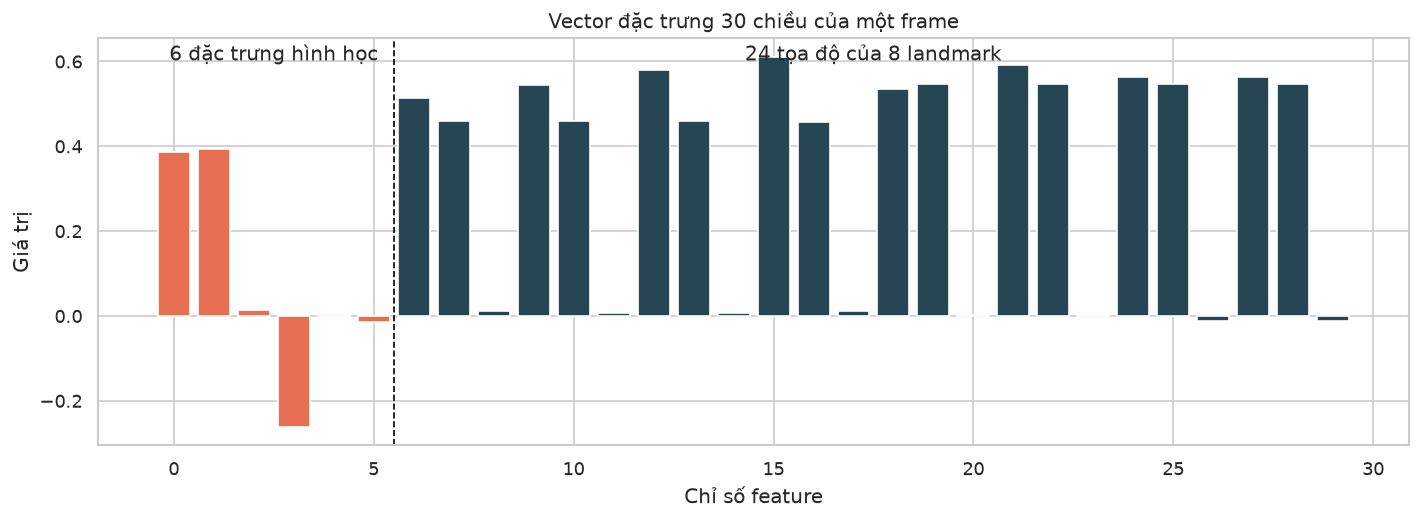

In [5]:
feature_30 = _build_frame_feature(face, feature_set='base')
feature_values = FEATURE_SCHEMA.copy()
feature_values['Giá trị tại frame'] = feature_30
assert feature_30.shape == (30,)
display(feature_values.style.format({'Giá trị tại frame': '{:.6f}'}))
feature_values.to_csv(OUT / 'gia_tri_feature_frame_cu_the.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(12, 4.5))
colors = ['#E76F51'] * 6 + ['#264653'] * 24
ax.bar(np.arange(30), feature_30, color=colors)
ax.axvline(5.5, color='black', ls='--', lw=1)
ax.text(2.5, ax.get_ylim()[1] * 0.92, '6 đặc trưng hình học', ha='center')
ax.text(17.5, ax.get_ylim()[1] * 0.92, '24 tọa độ của 8 landmark', ha='center')
ax.set(title='Vector đặc trưng 30 chiều của một frame', xlabel='Chỉ số feature', ylabel='Giá trị')
fig.tight_layout()
fig.savefig(OUT / '03_vector_30_chieu_mot_frame.png', bbox_inches='tight', facecolor='white')
plt.show()

## 5. Landmark và đặc trưng thay đổi như thế nào trong một video?

Notebook lấy đều 30 frame từ video. Nếu không phát hiện được khuôn mặt tại một frame, vector của frame đó được đặt bằng 0, đúng quy ước của extractor.

Shape raw: (30, 30) | Tỷ lệ phát hiện mặt: 100.0%


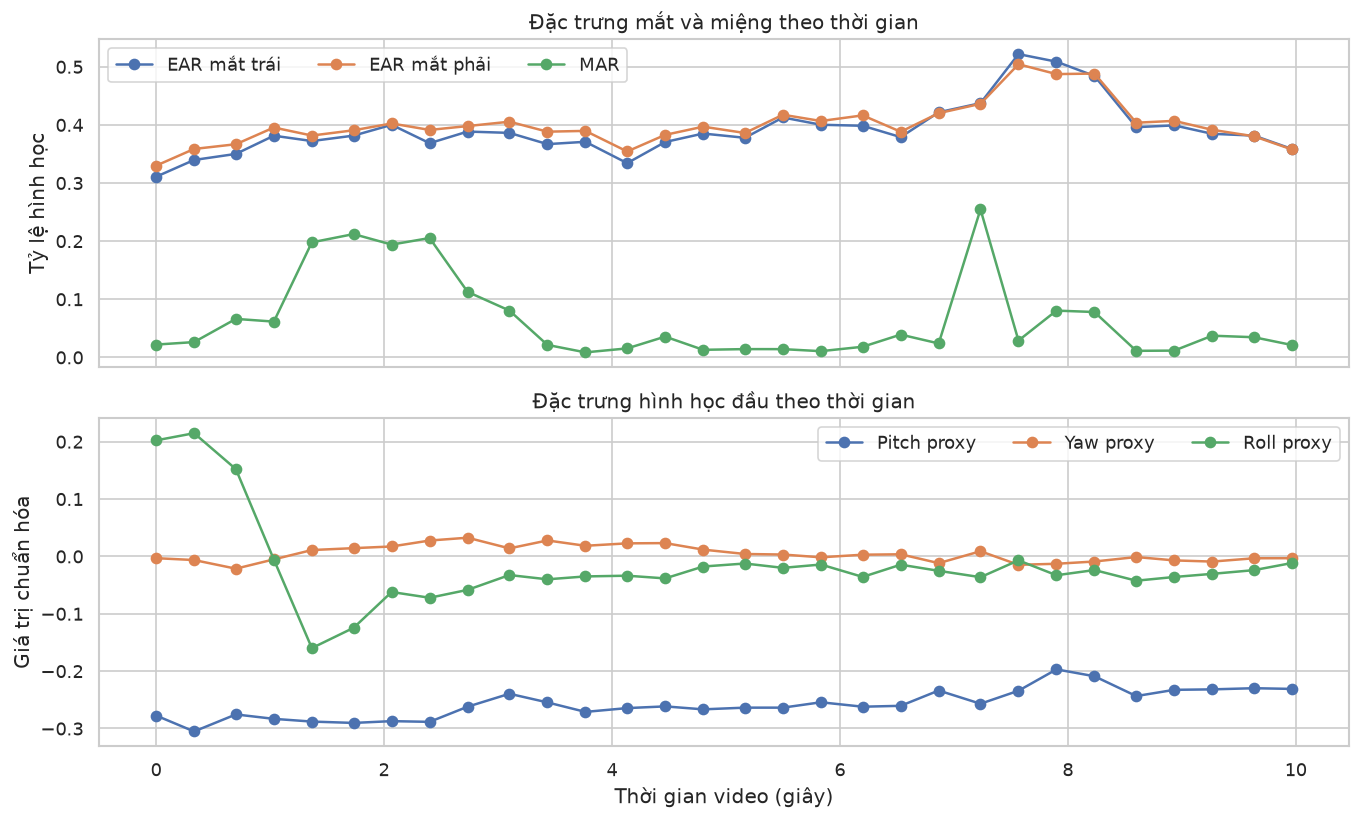

In [6]:
sample_indices = np.linspace(0, max(0, frame_count - 1), 30).round().astype(int)
sequence_30 = []
face_flags = []
cap = cv2.VideoCapture(str(VIDEO_PATH))
for frame_idx in sample_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, bgr = cap.read()
    if not ok:
        sequence_30.append(np.zeros(30, dtype=np.float32)); face_flags.append(False); continue
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    detected = detector.process(rgb)
    if detected.multi_face_landmarks:
        sequence_30.append(_build_frame_feature(detected.multi_face_landmarks[0], feature_set='base'))
        face_flags.append(True)
    else:
        sequence_30.append(np.zeros(30, dtype=np.float32)); face_flags.append(False)
cap.release()
sequence_30 = np.stack(sequence_30).astype(np.float32)
time_seconds = sample_indices / max(fps, 1e-6)
print('Shape raw:', sequence_30.shape, '| Tỷ lệ phát hiện mặt:', f'{np.mean(face_flags)*100:.1f}%')

fig, axes = plt.subplots(2, 1, figsize=(11.5, 7), sharex=True)
axes[0].plot(time_seconds, sequence_30[:, 0], marker='o', label='EAR mắt trái')
axes[0].plot(time_seconds, sequence_30[:, 1], marker='o', label='EAR mắt phải')
axes[0].plot(time_seconds, sequence_30[:, 2], marker='o', label='MAR')
axes[0].set(ylabel='Tỷ lệ hình học', title='Đặc trưng mắt và miệng theo thời gian')
axes[0].legend(ncol=3)
axes[1].plot(time_seconds, sequence_30[:, 3], marker='o', label='Pitch proxy')
axes[1].plot(time_seconds, sequence_30[:, 4], marker='o', label='Yaw proxy')
axes[1].plot(time_seconds, sequence_30[:, 5], marker='o', label='Roll proxy')
axes[1].set(xlabel='Thời gian video (giây)', ylabel='Giá trị chuẩn hóa', title='Đặc trưng hình học đầu theo thời gian')
axes[1].legend(ncol=3)
fig.tight_layout()
fig.savefig(OUT / '04_dac_trung_video_theo_thoi_gian.png', bbox_inches='tight', facecolor='white')
plt.show()

## 6. Làm giàu theo thời gian: từ 30 lên 90 chiều

Với mỗi feature gốc $x_t$, pipeline tạo thêm:

- **Vận tốc:** $\Delta x_t=x_t-x_{t-1}$; frame đầu có vận tốc bằng 0.
- **Độ lệch chuẩn cửa sổ:** $\sigma(x)$ được lặp lại tại cả 30 frame.

Do đó mỗi frame có $30+30+30=90$ chiều.

{'raw': (30, 30), 'velocity': (30, 30), 'std': (30, 30), 'enriched': (30, 90)}


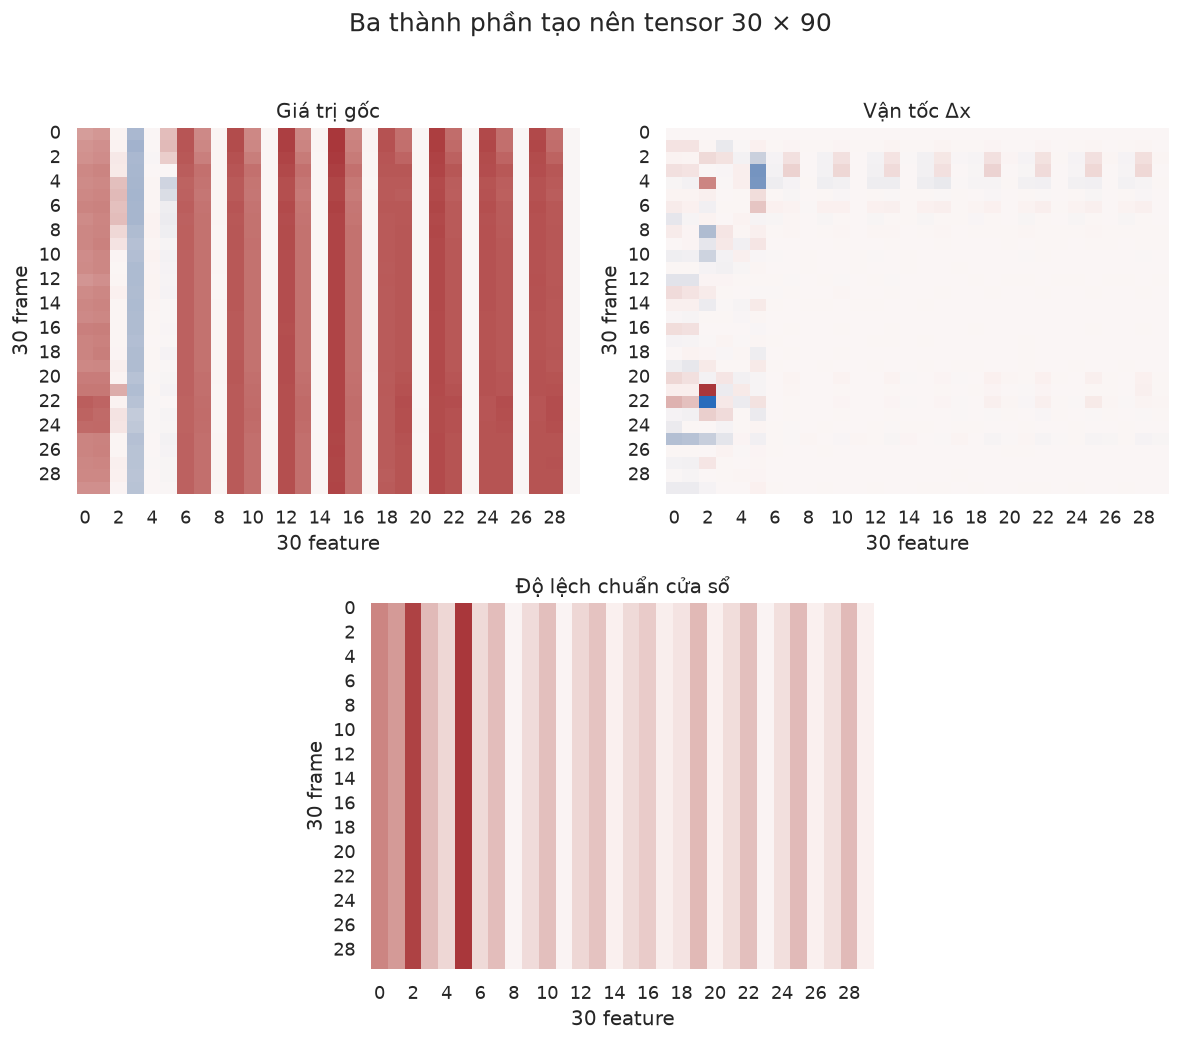

In [7]:
enriched_90 = _window_frames(list(sequence_30), feature_set='base', temporal_enrichment='velocity_std')[0]
assert enriched_90.shape == (30, 90)
raw_part = enriched_90[:, :30]
velocity_part = enriched_90[:, 30:60]
std_part = enriched_90[:, 60:90]
print({'raw': raw_part.shape, 'velocity': velocity_part.shape, 'std': std_part.shape, 'enriched': enriched_90.shape})

import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(10, 8.5))
gs = gridspec.GridSpec(2, 4, figure=fig)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2:])
ax3 = fig.add_subplot(gs[1, 1:3])

axes = [ax1, ax2, ax3]
parts = [('Giá trị gốc', raw_part), ('Vận tốc Δx', velocity_part), ('Độ lệch chuẩn cửa sổ', std_part)]
for ax, (title, matrix) in zip(axes, parts):
    sns.heatmap(matrix, cmap='vlag', center=0, cbar=False, ax=ax)
    ax.set(title=title, xlabel='30 feature', ylabel='30 frame')
    ax.tick_params(axis='y', rotation=0)
fig.suptitle('Ba thành phần tạo nên tensor 30 × 90', y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(OUT / '05_lam_giau_30_len_90.png', bbox_inches='tight', facecolor='white')
plt.show()


## 7. Xuất video minh họa landmark

Video đầu ra đánh dấu toàn bộ landmark bằng chấm xanh và các landmark tham gia tạo feature bằng chấm cam có chỉ số. Để notebook chạy nhanh, mặc định chỉ xuất tối đa 120 frame đầu.

In [8]:
annotated_path = OUT / 'video_landmark_minh_hoa.mp4'
cap = cv2.VideoCapture(str(VIDEO_PATH))
video_fps = float(cap.get(cv2.CAP_PROP_FPS) or 25.0)
video_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) or width)
video_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or height)
writer = cv2.VideoWriter(str(annotated_path), cv2.VideoWriter_fourcc(*'mp4v'), video_fps, (video_w, video_h))
max_output_frames = min(120, int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 120))
written = 0
while written < max_output_frames:
    ok, bgr = cap.read()
    if not ok:
        break
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    detected = detector.process(rgb)
    if detected.multi_face_landmarks:
        current = detected.multi_face_landmarks[0]
        current_pts = np.asarray([[lm.x * video_w, lm.y * video_h] for lm in current.landmark], dtype=int)
        for x, y in current_pts:
            cv2.circle(bgr, (int(x), int(y)), 1, (100, 220, 120), -1)
        for idx in selected_ids:
            x, y = current_pts[idx]
            cv2.circle(bgr, (int(x), int(y)), 3, (0, 120, 255), -1)
            cv2.putText(bgr, str(idx), (int(x)+3, int(y)-3), cv2.FONT_HERSHEY_SIMPLEX, 0.28, (0, 255, 255), 1, cv2.LINE_AA)
    writer.write(bgr)
    written += 1
cap.release()
writer.release()
detector.close()
print('Đã ghi:', annotated_path, '| số frame:', written)
display(Video(str(annotated_path), embed=False, width=720))

print('Các đầu ra đã tạo:')
for path in sorted(OUT.iterdir()):
    print('-', path.relative_to(ROOT))

Đã ghi: /home/bear/Documents/Workspace/Thesis20252/engagement-cpu/notebooks/preprocess/video_landmark_minh_hoa.mp4 | số frame: 120


Các đầu ra đã tạo:
- notebooks/preprocess/01_cac_buoc_phat_hien_landmark.png
- notebooks/preprocess/02_nhom_landmark_tao_dac_trung.png
- notebooks/preprocess/03_vector_30_chieu_mot_frame.png
- notebooks/preprocess/04_dac_trung_video_theo_thoi_gian.png
- notebooks/preprocess/05_lam_giau_30_len_90.png
- notebooks/preprocess/feature_schema_30.csv
- notebooks/preprocess/gia_tri_feature_frame_cu_the.csv
- notebooks/preprocess/preprocess.ipynb
- notebooks/preprocess/video_landmark_minh_hoa.mp4
